<a href="https://colab.research.google.com/github/vyasathul17/Machine-Learning/blob/main/Random_Forest_Handson.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving customer_churn.csv to customer_churn.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv("customer_churn.csv")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [ ]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"],errors = "coerce")

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df.dropna(inplace =True)

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df.drop(["customerID"],inplace = True,axis = 1)

In [ ]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [ ]:
df["Partner"] = df["Partner"].map({"Yes":1,"No":0})
df["Dependents"] = df["Dependents"].map({"Yes":1,"No":0})
df["MultipleLines"] = df["MultipleLines"].map({"No phone service":0,"No":1,"Yes":2})
df["InternetService"] = df["InternetService"].map({"DSL":0,"Fiber optics":1,"No":2})
df["OnlineSecurity"] = df["OnlineSecurity"].map({"Yes":1,"No":0,"No internet service":2})
df["OnlineBackup"] = df["OnlineBackup"].map({"Yes":1,"No":0,"No internet service":2})
df["DeviceProtection"] = df["DeviceProtection"].map({"Yes":1,"No":0,"No internet service":2})
df["TechSupport"] = df["TechSupport"].map({"Yes":1,"No":0,"No internet service":2})
df["StreamingTV"] = df["StreamingTV"].map({"Yes":1,"No":0,"No internet service":2})
df["StreamingMovies"] = df["StreamingMovies"].map({"Yes":1,"No":0,"No internet service":2})
df["Contract"] = df["Contract"].map({'Month-to-month':0, 'One year':1, 'Two year':2})
df["PaperlessBilling"] = df["PaperlessBilling"].map({"Yes":1,"No":0})
df["PaymentMethod"] = df["PaymentMethod"].map({"Electronic check":0,"Mailed check":1,"Bank transfer (automatic)":2,"Credit card (automatic)":3})


In [ ]:
df.dtypes

,0
gender,object
SeniorCitizen,int64
Partner,int64
Dependents,int64
tenure,int64
PhoneService,object
MultipleLines,int64
InternetService,float64
OnlineSecurity,int64
OnlineBackup,int64


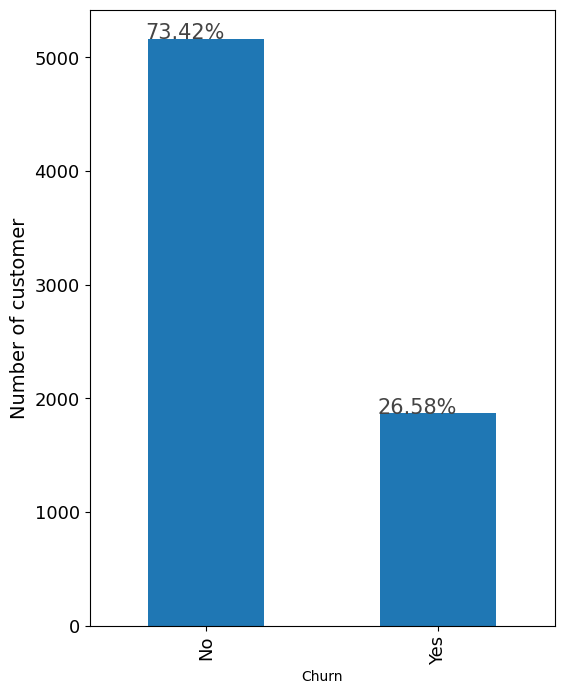

In [ ]:
ax = df["Churn"].value_counts().plot(kind = "bar",figsize =(6,8),fontsize = 13)
ax.set_ylabel("Number of customer",fontsize = 14);

totals = []
for i in ax.patches:
  totals.append(i.get_height())


total = sum(totals)

for i in ax.patches:
  ax.text(i.get_x() - .01,i.get_height() + .5,\
          str(round((i.get_height()/total)*100,2))+"%",fontsize =15,
          color = "#444444")
plt.show()

In [ ]:
import seaborn as sns

<Axes: xlabel='MonthlyCharges', ylabel='tenure'>

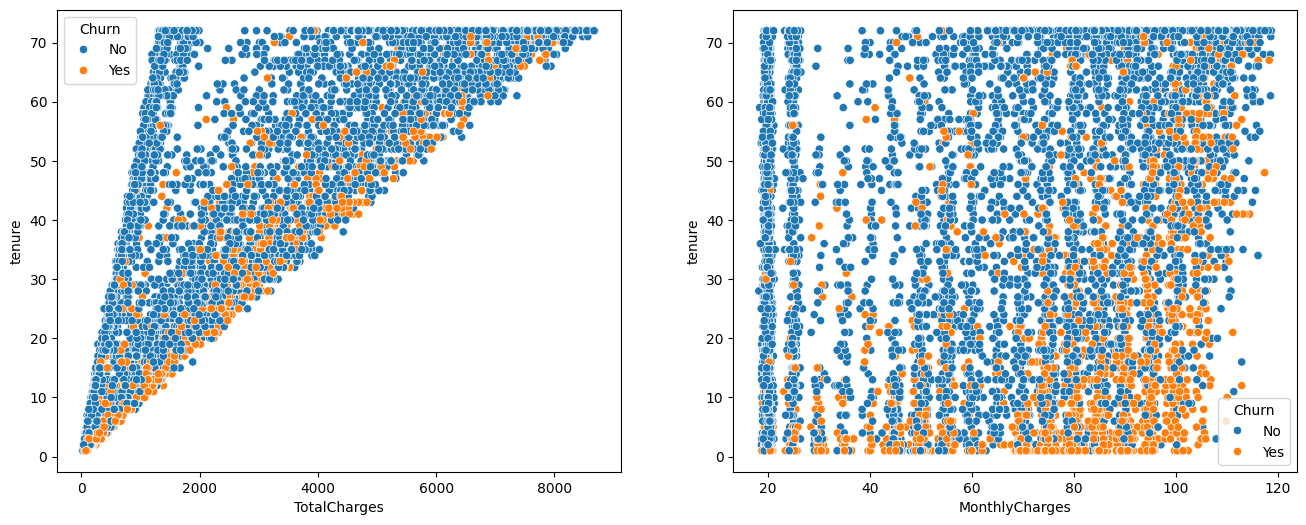

In [ ]:
_,ax = plt.subplots(1,2,figsize= (16,6))
sns.scatterplot(data=df,x = "TotalCharges",y = "tenure",hue = "Churn",ax = ax[0])
sns.scatterplot(data=df,x = "MonthlyCharges",y = "tenure",hue ="Churn",ax = ax[1])

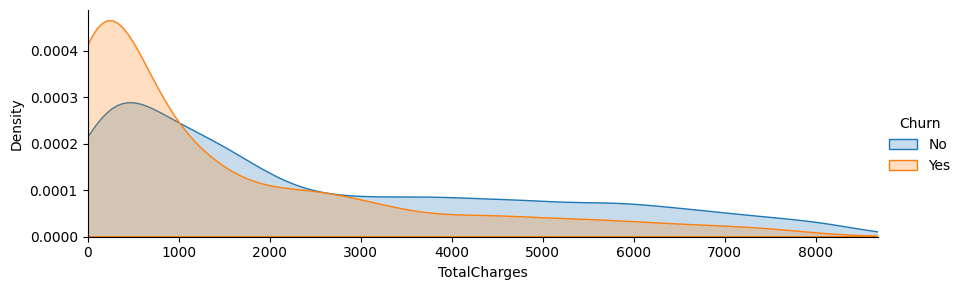

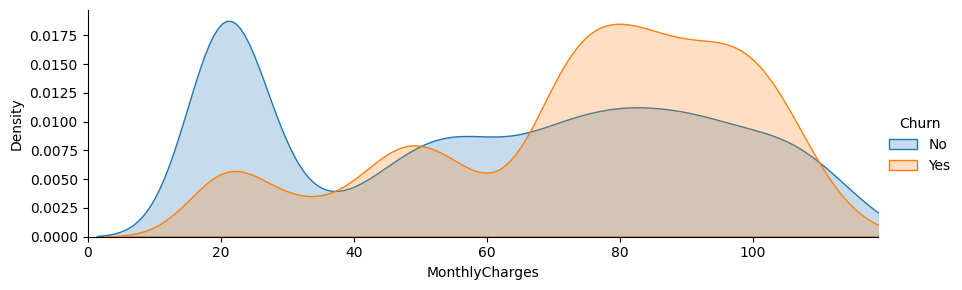

In [ ]:
facet = sns.FacetGrid(df,hue = "Churn",aspect = 3)
facet.map(sns.kdeplot,"TotalCharges",shade = True)
facet.set(xlim = (0,df["TotalCharges"].max()))
facet.add_legend()


facet = sns.FacetGrid(df,hue = "Churn",aspect = 3)
facet.map(sns.kdeplot,"MonthlyCharges",shade = True)
facet.set(xlim = (0,df["MonthlyCharges"].max()))
facet.add_legend()

In [ ]:
num_col = df.select_dtypes(include = ["int64","float64"])
num_corr = num_col.corr()
num_corr

,SeniorCitizen,Partner,Dependents,tenure,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.016957,-0.210550,0.015683,0.113769,-0.131737,-0.210546,-0.152380,-0.156700,-0.223438,-0.129721,-0.120658,-0.141820,0.156258,-0.093712,0.219874,0.102411
Partner,0.016957,1.000000,0.452269,0.381912,0.118037,0.000437,0.081078,0.086346,0.093391,0.068277,0.079066,0.075310,0.294094,-0.013957,0.133280,0.097825,0.319072
Dependents,-0.210550,0.452269,1.000000,0.163386,-0.019178,0.088943,0.188889,0.160845,0.154819,0.179176,0.138809,0.125086,0.240556,-0.110131,0.124002,-0.112343,0.064653
tenure,0.015683,0.381912,0.163386,1.000000,0.259112,-0.043914,0.147575,0.180896,0.180895,0.146727,0.138208,0.142143,0.676734,0.004823,0.340939,0.246862,0.825880
MultipleLines,0.113769,0.118037,-0.019178,0.259112,1.000000,0.164014,-0.066695,-0.007500,-0.012819,-0.066814,0.030524,0.027944,0.084037,0.133538,0.026248,0.491412,0.412495
InternetService,-0.131737,0.000437,0.088943,-0.043914,0.164014,1.000000,0.883019,0.888832,0.890239,0.883135,0.898047,0.896007,0.180245,-0.251398,0.054307,-0.815004,-0.424023
OnlineSecurity,-0.210546,0.081078,0.188889,0.147575,-0.066695,0.883019,1.000000,0.751312,0.748684,0.790951,0.701526,0.704672,0.389138,-0.333656,0.214330,-0.620532,-0.153234
OnlineBackup,-0.152380,0.086346,0.160845,0.180896,-0.007500,0.888832,0.751312,1.000000,0.740244,0.753752,0.720277,0.716388,0.350419,-0.261565,0.183555,-0.537727,-0.085017
DeviceProtection,-0.156700,0.093391,0.154819,0.180895,-0.012819,0.890239,0.748684,0.740244,1.000000,0.767659,0.762742,0.766635,0.389480,-0.275519,0.192405,-0.512604,-0.077394
TechSupport,-0.223438,0.068277,0.179176,0.146727,-0.066814,0.883135,0.790951,0.753752,0.767659,1.000000,0.737211,0.737126,0.417691,-0.310354,0.217412,-0.596805,-0.141011


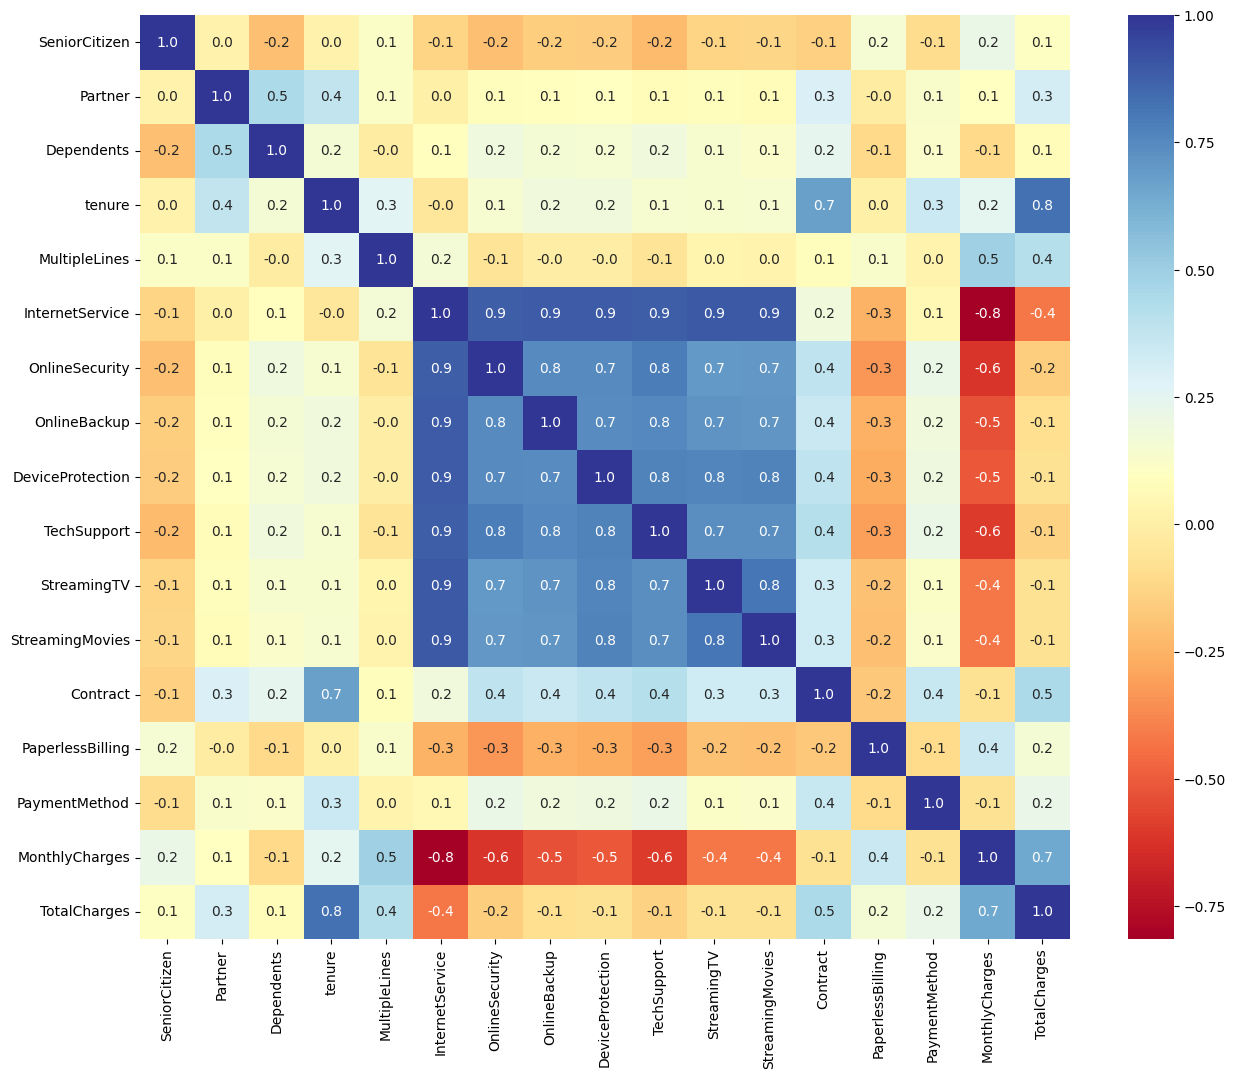

In [ ]:
plt.figure(figsize = (15,12))
sns.heatmap(num_corr,cmap = "RdYlBu",annot = True,fmt = ".1f")
plt.show()

In [ ]:
df["Churn"] = df["Churn"].map({"Yes":1,"No":0})

In [ ]:
df = df.drop(["gender","PhoneService"],axis = 1)


In [ ]:
x = df.iloc[:,:-1].values
y = df.iloc[:,-1].values

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [ ]:
rf = RandomForestClassifier()
rf1 = rf.fit(x_train,y_train)


In [ ]:
pred = rf1.predict(x_test)


In [ ]:
accuracy_score(y_test,pred)

0.7853589196872779

### Hyperparamtre Tuning

**Hyper-parameters**  are parameters that define the model structure, and **tuning** hyper-parameters is the process of finding the best model structure. So that model  structure makes the model more efficient

There are many parameters which we can look into while building the randomforest model they are:

**bootstrap'/max_sample:** The max_samples hyperparameter determines what fraction of the original dataset is given to any individual tree

**'max_depth':** The max_depth of a tree in Random Forest is defined as the longest path between the root node and the leaf node

**'max_features':** This resembles the number of maximum features provided to each tree in a random forest.

**'min_samples_leaf':** This Random Forest hyperparameter specifies the minimum number of samples that should be present in the leaf node after splitting a node.

**'min_samples_split':** parameter that tells the decision tree in a random forest the minimum required number of observations in any given node in order to split it.

**'n_estimators':**
number of decision trees to choose while fitting the random forest model

There are two techniques for hyper parameter tuning :
    1.RandomizedSearchCV
    2.GridSearchCV
    
For our model we will be implementing  RandomizedSearchCV method and tune our model

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
  # Number of trees in random forest
n_estimators = [int(x) for x in np.linspace(start = 200,stop = 2000,num =10)]
  # Number of features to consider at every split
max_features = ["auto","sqrt"]
  # Maximum number of levels in tree
max_depth = [int(x) for x in np.linspace(10,110,num = 11)]
max_depth.append(None)
  # Minimum number of samples required to split a node
min_samples_split = [2,5,10]
  # Minimum number of samples required at each leaf node
min_samples_leaf = [1,2,4]
  # Method of selecting samples for training each tree
bootstrap = [True,False]


  #create the random grid

random_grid = {"n_estimators": n_estimators,
                 "max_features":max_features,
                 "max_depth":max_depth,
                 "min_samples_split":min_samples_split,
                 "min_samples_leaf":min_samples_leaf,
                 "bootstrap": bootstrap}

print(random_grid)

{'n_estimators': [200, 400, 600, 800, 1000, 1200, 1400, 1600, 1800, 2000], 'max_features': ['auto', 'sqrt'], 'max_depth': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, None], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4], 'bootstrap': [True, False]}


Steps to implement:
    

1.Use the random grid to search for best hyperparameters

2.First create the base model to tune

3.Random search of parameters, using 3 fold cross validation

4.search across 10 different combinations, and use all available cores

5.Fit the random search model

In [ ]:
# Use the random grid to search for best hyperparameters
# First create the base model to tune

rf = RandomForestClassifier(random_state = 42)
# Random search of parameters, using 3 fold cross validation,
# search across 100 different combinations, and use all available cores

rf_random = RandomizedSearchCV(estimator = rf,param_distributions = random_grid,
                               n_iter = 10,scoring = "neg_mean_absolute_error",
                               cv = 3,verbose = 2,random_state = 42,n_jobs = 1,
                               return_train_score = True)
# Fit the random search model
rf2 = rf_random.fit(x_train,y_train);

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END bootstrap=True, max_depth=50, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=200; total time=   1.3s
[CV] END bootstrap=True, max_depth=50, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=200; total time=   1.1s
[CV] END bootstrap=True, max_depth=50, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=200; total time=   1.2s
[CV] END bootstrap=False, max_depth=90, max_features=sqrt, min_samples_leaf=4, min_samples_split=10, n_estimators=600; total time=   5.1s
[CV] END bootstrap=False, max_depth=90, max_features=sqrt, min_samples_leaf=4, min_samples_split=10, n_estimators=600; total time=   4.2s
[CV] END bootstrap=False, max_depth=90, max_features=sqrt, min_samples_leaf=4, min_samples_split=10, n_estimators=600; total time=   9.2s
[CV] END bootstrap=False, max_depth=60, max_features=auto, min_samples_leaf=2, min_samples_split=2, n_estimators=6

In [ ]:
rf2.best_params_

{'n_estimators': 600,
 'min_samples_split': 10,
 'min_samples_leaf': 4,
 'max_features': 'sqrt',
 'max_depth': 90,
 'bootstrap': False}

In [ ]:
pred = rf2.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,pred)

0.7967306325515281

In [ ]:
df.columns

Index(['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges',
       'Churn'],
      dtype='object')